# 02 — Scaling, PCA & t-SNE
We standardize the numeric features (required for any distance-based
algorithm), then use PCA and t-SNE purely as **visualization** tools
to sanity-check that clusterable structure exists before we run
K-Means / Hierarchical / DBSCAN in the next notebook.

Note: with only 3 numeric features, PCA isn't really *reducing*
dimensionality in a meaningful way here — it mainly exists so this
notebook generalizes to a version of the dataset with more engineered
features (e.g. recency/frequency/monetary, category spend, etc).

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from src.preprocessing import load_raw_data, get_feature_matrix, fit_scaler, FEATURE_COLUMNS

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("../data/processed/mall_customers_clean.csv")
X = get_feature_matrix(df)
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,34,88,77
1,38,52,54
2,28,65,43
3,20,28,82
4,46,21,37


## Standardize features
This scaler is the SAME object we'll save with joblib and reuse
at prediction time in FastAPI/Streamlit — fit only on training data.

In [3]:
scaler = fit_scaler(X)
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-0.40573324,  0.67046419,  0.8776777 ],
       [-0.08468364, -0.29223038,  0.0560091 ],
       [-0.88730765,  0.05540933, -0.33696284],
       [-1.52940686, -0.93402675,  1.05630131],
       [ 0.55741557, -1.12121736, -0.55131117]])

## PCA — variance explained

In [4]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

Explained variance ratio per component: [0.53746029 0.32866529 0.13387442]
Cumulative: [0.53746029 0.86612558 1.        ]


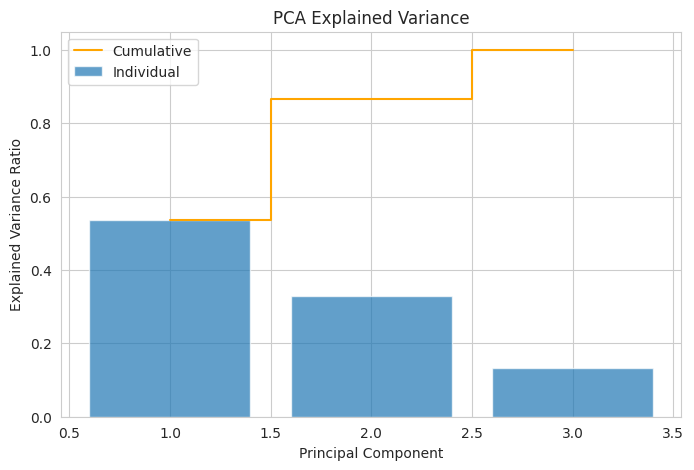

In [5]:
plt.bar(range(1, 4), pca.explained_variance_ratio_, alpha=0.7, label="Individual")
plt.step(range(1, 4), np.cumsum(pca.explained_variance_ratio_), where="mid", label="Cumulative", color="orange")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.title("PCA Explained Variance")
plt.savefig("../reports/figures/02_pca_variance.png", dpi=120)
plt.show()

## PCA — 2D projection

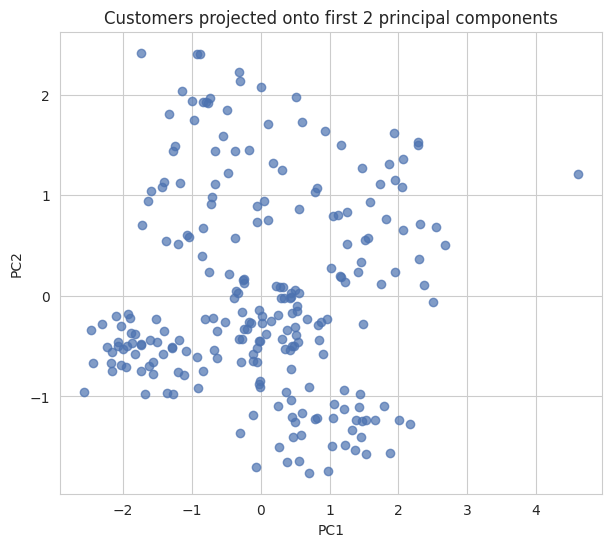

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c="#4C72B0")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers projected onto first 2 principal components")
plt.savefig("../reports/figures/02_pca_2d.png", dpi=120)
plt.show()

## t-SNE — 2D projection
t-SNE is purely for visualization (never for feeding into a downstream
model) — it exaggerates local structure and helps confirm clusters
visually before we commit to K-Means/DBSCAN.

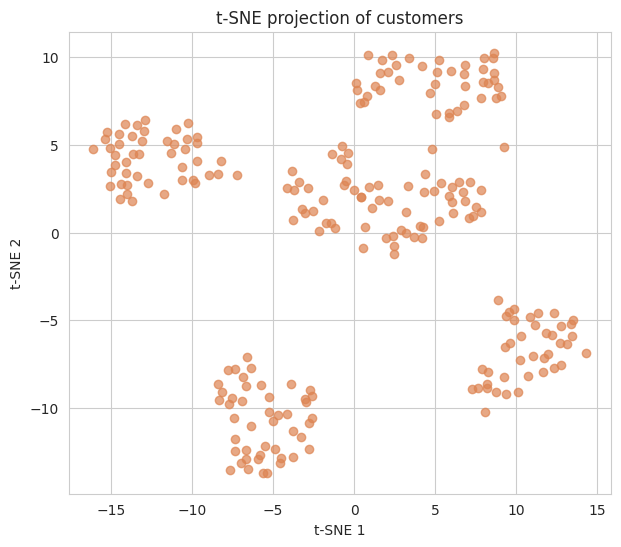

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, c="#DD8452")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection of customers")
plt.savefig("../reports/figures/02_tsne_2d.png", dpi=120)
plt.show()

## Save scaler for reuse
Saved now so notebook 03/04/05 (and later the FastAPI app) all use
the exact same fitted StandardScaler.

In [8]:
joblib.dump(scaler, "../models/scaler.joblib")
print("Scaler saved to models/scaler.joblib")

Scaler saved to models/scaler.joblib


## Notes
- t-SNE plot should show visibly separated blobs — if it's one big blob,
  that's a sign the features need more engineering before clustering will
  be meaningful.
- We're keeping PCA components around mainly for the notebook workflow;
  actual clustering in the next notebook will run on the scaled *original*
  3 features, since PCA at only 3 input dims doesn't buy much and makes
  cluster interpretation (in terms of Age/Income/Spending) harder.